In [ ]:

df = pd.read_csv('data/processed/defunciones_clean.csv', encoding='utf-8-sig')

# ── BLOQUE A: VISIÓN GENERAL ───────────────────────────────────

# Distribución por sexo
sexo_totales = df.groupby('sexo')['defunciones'].sum().sort_values(ascending=False)
print(sexo_totales)

# ── BLOQUE B: TOP CAUSAS ───────────────────────────────────────
# Los códigos CIE-10 tienen categorías — primeras 3 letras = capítulo
df['categoria_cie'] = df['cod_causa'].str[:3]

top_causas = (df.groupby('cod_causa')['defunciones']
                .sum()
                .sort_values(ascending=False)
                .head(15))

# Diccionario de causas frecuentes para etiquetar (podés ampliar)
causas_labels = {
     # Generales
    'J18': 'Neumonía',
    'I50': 'Insuf. cardíaca',
    'R99': 'Causas mal definidas',
    'I21': 'Infarto agudo',
    'J96': 'Insuf. respiratoria',
    'A41': 'Sepsis',
    'C34': 'T.M. pulmón',
    'I47': 'Taquicardia parox.',
    'I64': 'ACV',
    'C18': 'T.M. colon',
    'I49': 'Arritmia',
    'E14': 'Diabetes',
    'C50': 'T.M. mama',
    'J44': 'EPOC',
    'N39': 'Inf. urinaria',
    # Causas externas
    'X70': 'Suicidio',
    'Y20': 'Int. no determinada',
    'Y34': 'Int. no det. (otras)',
    'X95': 'Agresión arma de fuego',
    'X59': 'Exposición factores',
    'V23': 'Accidente de moto',
    'Y24': 'Disparo no determinado',
    # Neonatal
    'P22': 'Distrés respiratorio neonatal',
    'P07': 'Prematurez / bajo peso',
    'P36': 'Sepsis neonatal',
    'P28': 'Otros prob. respiratorios perinatales',
    'Q24': 'Malformación cardíaca congénita',
    # Infancia temprana
    'R95': 'Muerte súbita del lactante',
    # Niñez
    'C91': 'Leucemia linfoblástica',
    'G80': 'Parálisis cerebral',
    'G93': 'Otros trastornos cerebrales',

}
top_causas.index = [causas_labels.get(c, c) for c in top_causas.index]

# ── BLOQUE C: ANÁLISIS POR PROVINCIA ──────────────────────────
por_provincia = (df[~df['provincia'].isin(['Sin especificar', 'Otra/Extranjero'])]
                   .groupby('provincia')['defunciones']
                   .sum()
                   .sort_values(ascending=False))

# ── BLOQUE D: PERFIL DEMOGRÁFICO ──────────────────────────────
# Ordenar grupos de edad correctamente usando el prefijo numérico
edad_orden = (df[['grupo_edad_orden', 'grupo_edad_label']]
              .drop_duplicates()
              .sort_values('grupo_edad_orden'))

por_edad = (df.groupby(['grupo_edad_orden', 'grupo_edad_label'])['defunciones']
              .sum()
              .reset_index()
              .sort_values('grupo_edad_orden'))

# Cruce edad × sexo
edad_sexo = (df[df['sexo'].isin(['Masculino', 'Femenino'])]
               .groupby(['grupo_edad_label', 'grupo_edad_orden', 'sexo'])['defunciones']
               .sum()
               .reset_index()
               .sort_values('grupo_edad_orden'))

sexo
Masculino          188750
Femenino           187335
Sin especificar        46
Indeterminado          10
Name: defunciones, dtype: int64


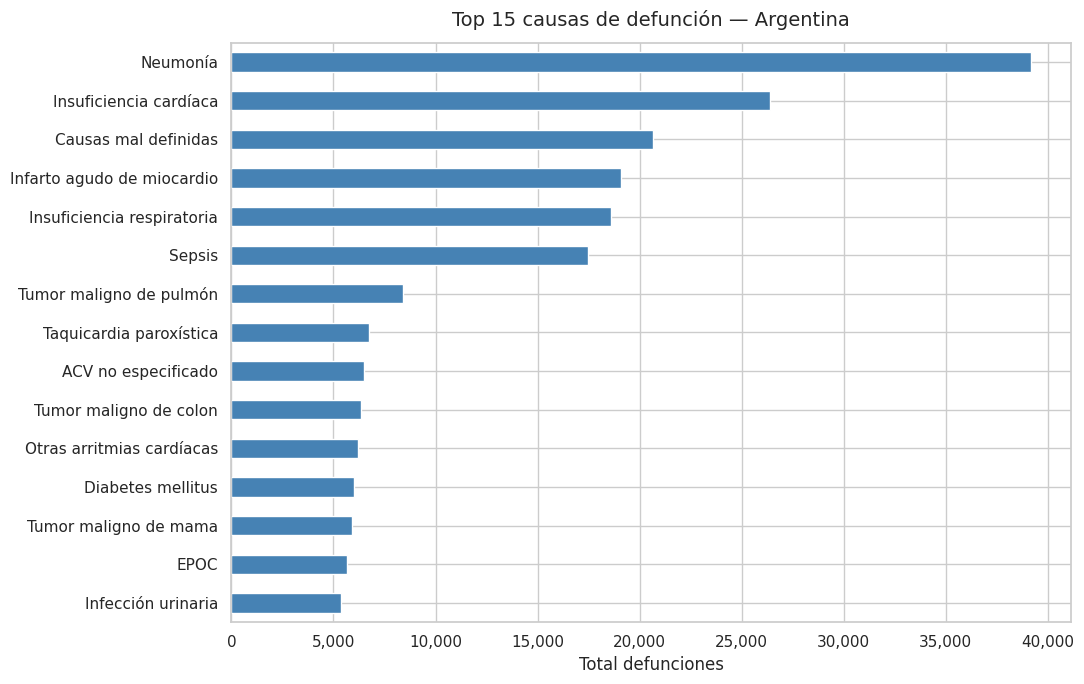

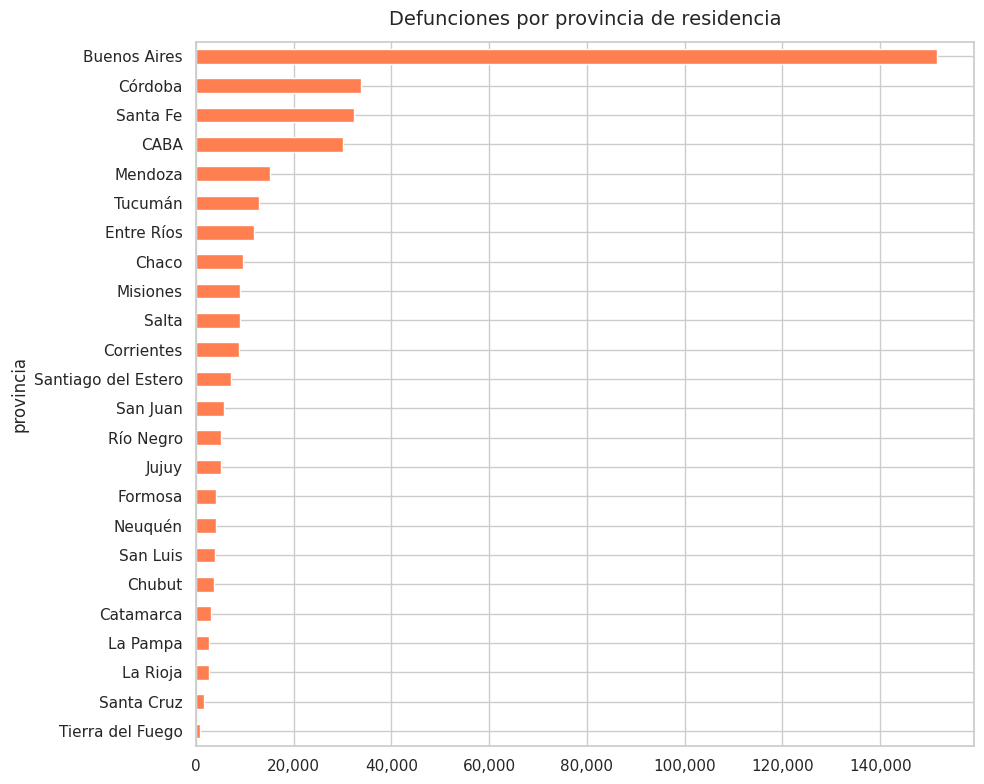

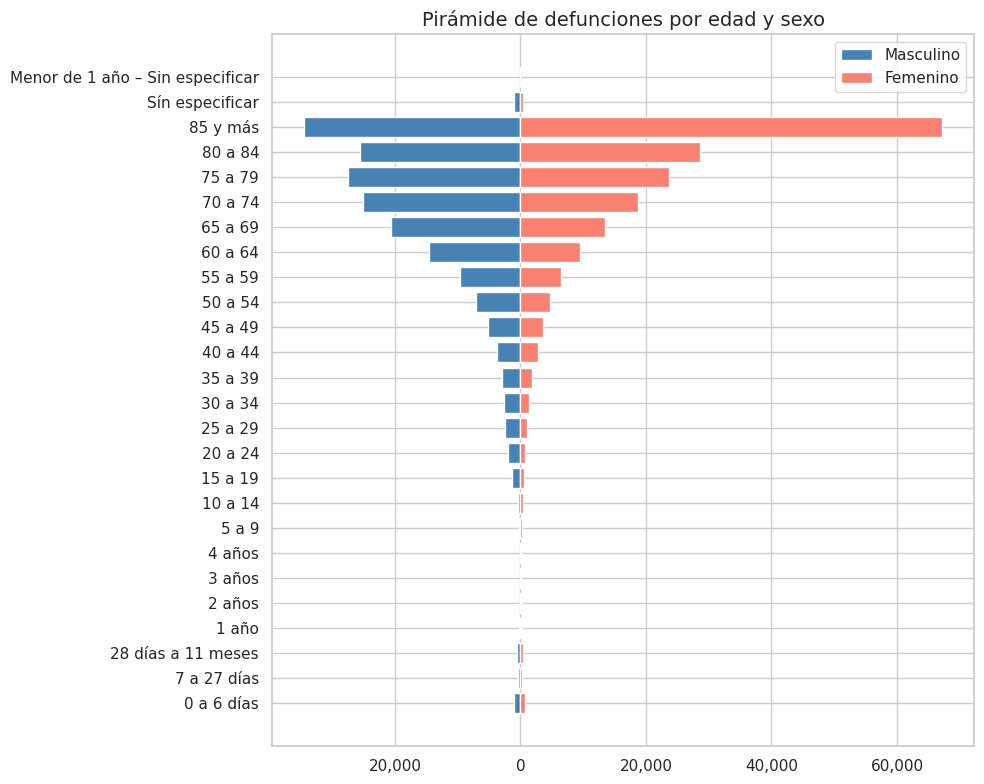

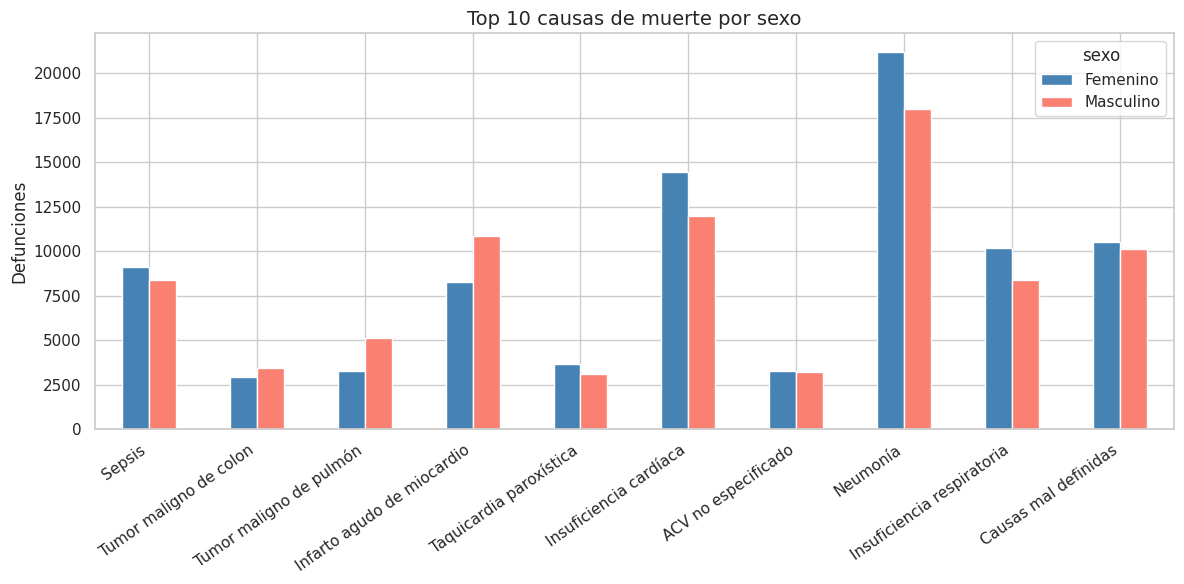

In [ ]:


sns.set_theme(style='whitegrid', palette='muted')
fig_path = 'outputs/figures/'
os.makedirs(fig_path, exist_ok=True) # Create the directory if it doesn't exist

# ── VIZ 1: Top 15 causas de muerte ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
top_causas.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 causas de defunción — Argentina', fontsize=14, pad=12)
ax.set_xlabel('Total defunciones')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{fig_path}top15_causas.png', dpi=150)

# ── VIZ 2: Defunciones por provincia ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
por_provincia.sort_values().plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title('Defunciones por provincia de residencia', fontsize=14, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{fig_path}defunciones_provincia.png', dpi=150)

# ── VIZ 3: Pirámide de edad × sexo ────────────────────────────
masc = edad_sexo[edad_sexo['sexo'] == 'Masculino'].set_index('grupo_edad_label')['defunciones']
fem  = edad_sexo[edad_sexo['sexo'] == 'Femenino'].set_index('grupo_edad_label')['defunciones']
labels = por_edad['grupo_edad_label'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(labels, -masc.reindex(labels).fillna(0), color='steelblue', label='Masculino')
ax.barh(labels,  fem.reindex(labels).fillna(0),  color='salmon',    label='Femenino')
ax.set_title('Pirámide de defunciones por edad y sexo', fontsize=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x)):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{fig_path}piramide_edad_sexo.png', dpi=150)

# ── VIZ 4: Top causas por sexo (comparación) ──────────────────
top10_causas_cod = (df.groupby('cod_causa')['defunciones']
                      .sum().nlargest(10).index.tolist())

df_top = df[df['cod_causa'].isin(top10_causas_cod) &
            df['sexo'].isin(['Masculino', 'Femenino'])]

pivot = (df_top.groupby(['cod_causa', 'sexo'])['defunciones']
               .sum().unstack())
pivot.index = [causas_labels.get(c, c) for c in pivot.index]

pivot.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Top 10 causas de muerte por sexo', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Defunciones')
plt.tight_layout()
plt.savefig(f'{fig_path}top10_por_sexo.png', dpi=150)